Stock Coverage (Days of Supply): Why a Fixed Threshold Can Mislead

Author: Alex Coronel

A short data analysis showing that, when measuring how many days of inventory a product has left, the consumption window used to estimate demand matters more than the alert threshold applied on top of it.

⚠️ Data disclaimer: All data in this notebook is completely synthetic, generated randomly by generate_synthetic_data.py. It does not represent any real company, client, or dataset. This project illustrates an analysis methodology, not a specific business case.

The question

Stock coverage (Days of Supply) answers a simple operational question:

How many days will current inventory last, at the rate the product is being consumed?


Days of Coverage =  Current Stock / Average Daily Consumption
	

The calculation looks trivial, but it hides one decision that changes the result entirely: over what time window do I measure "average daily consumption"? The last 7 days? 30? 90? This project shows that this choice can flip a product's risk classification — even when the stock and the threshold stay exactly the same.

1. LOAD THE DATA

Three synthetic tables:

products — the catalog: one row per product (SKU) and its category.
daily_consumption — the demand history: one row per product per day (40 products × 180 days = 7,200 rows).
inventory — a snapshot of current stock: one row per product.

daily_consumption is read with parse_dates=["date"] so the date column is treated as real dates — this is what later allows filtering by time window.

In [45]:
import pandas as pd
products = pd.read_csv("data/products.csv")
products.head()

,sku_id,category,base_daily_consumption
0,SKU-0001,Electronics,19.07
1,SKU-0002,Office,9.19
2,SKU-0003,Office,24.28
3,SKU-0004,Sports,22.38
4,SKU-0005,Sports,19.57


In [47]:
current_inventory = pd.read_csv("data/current_inventory.csv")
current_inventory.head()

,sku_id,cutoff_date,current_stock
0,SKU-0001,2025-06-29,703
1,SKU-0002,2025-06-29,776
2,SKU-0003,2025-06-29,937
3,SKU-0004,2025-06-29,406
4,SKU-0005,2025-06-29,44


In [48]:
daily_consumption = pd.read_csv("data/daily_consumption.csv", parse_dates=["date"])
daily_consumption.head()

,sku_id,date,units_consumed
0,SKU-0001,2025-01-01,15
1,SKU-0001,2025-01-02,24
2,SKU-0001,2025-01-03,35
3,SKU-0001,2025-01-04,57
4,SKU-0001,2025-01-05,22


In [49]:
daily_consumption.shape

(7200, 3)

In [50]:
products.shape

(40, 3)

In [51]:
current_inventory.shape

(40, 3)

2. AVERAGE DAILY CONSUMPTION

The consumption table has 7,200 rows. To compute coverage I need a single number per product: its average daily consumption. I collapse the daily rows into one value per product by grouping by sku_id and taking the mean.

In [52]:
avg_consumption = daily_consumption.groupby("sku_id")["units_consumed"].mean()
avg_consumption.head()

sku_id
SKU-0001    26.888889
SKU-0002    12.861111
SKU-0003    32.077778
SKU-0004    31.788889
SKU-0005    27.888889
Name: units_consumed, dtype: float64

3. DAYS OF COVERAGE

Average consumption and current stock live in two separate tables. I join them on sku_id (a merge — the same idea as a SQL JOIN) so each product's stock is matched with its own average consumption, then divide:

Days of coverage = current stock ÷ average daily consumption

In [53]:

avg_consumption = avg_consumption.reset_index()

avg_consumption = avg_consumption.rename(columns={"units_consumed": "avg_daily_consumption"})

coverage = current_inventory.merge(avg_consumption, on="sku_id", how="left")

coverage["days_of_coverage"] = coverage["current_stock"] / coverage["avg_daily_consumption"]

coverage.head()

,sku_id,cutoff_date,current_stock,avg_daily_consumption,days_of_coverage
0,SKU-0001,2025-06-29,703,26.888889,26.144628
1,SKU-0002,2025-06-29,776,12.861111,60.336933
2,SKU-0003,2025-06-29,937,32.077778,29.210253
3,SKU-0004,2025-06-29,406,31.788889,12.771758
4,SKU-0005,2025-06-29,44,27.888889,1.577689


4. THE SAME CALCULATION OVER THREE WINDOWS

So far the average used all 180 days. But recent demand can differ sharply from demand three months ago — a product can be quiet this week yet have sold heavily earlier (seasonality, one-off events, irregular demand patterns).

To test the effect, I recompute coverage using three different consumption windows — the last 7, 30, and 90 days — and place them side by side. This is where treating date as a real date pays off: I filter each window with a Timedelta counted back from the most recent day in the data.

In [54]:
cutoff_date = daily_consumption["date"].max()

def avg_consumption_last(n_days):
    start = cutoff_date - pd.Timedelta(days=n_days)
    window = daily_consumption[daily_consumption["date"] >= start]
    return window.groupby("sku_id")["units_consumed"].mean()

In [55]:
avg_consumption_last(7).head()     

sku_id
SKU-0001    19.375
SKU-0002    11.125
SKU-0003    20.625
SKU-0004    26.875
SKU-0005    21.500
Name: units_consumed, dtype: float64

In [56]:
avg_consumption_last(30).head() 

sku_id
SKU-0001    21.225806
SKU-0002    12.064516
SKU-0003    24.322581
SKU-0004    24.064516
SKU-0005    19.193548
Name: units_consumed, dtype: float64

In [57]:
avg_consumption_last(90).head()

sku_id
SKU-0001    24.428571
SKU-0002    12.120879
SKU-0003    31.054945
SKU-0004    27.593407
SKU-0005    26.923077
Name: units_consumed, dtype: float64

5. THE FIXED-THRESHOLD PROBLEM

A common practice is to set a fixed threshold — e.g. 60 days — and flag every product below it as "at risk". But if the verdict depends on the window used to estimate demand, the threshold gives a false sense of precision.

For each window I mark whether a product falls below the 60-day threshold, then count how many products change classification between the 7-day and 90-day windows.

In [58]:
comparison = current_inventory[["sku_id", "current_stock"]].copy()

for n in [7, 30, 90]:
    avg = avg_consumption_last(n)
    comparison[f"coverage_{n}d"] = comparison["current_stock"] / comparison["sku_id"].map(avg)

comparison.head(10)

,sku_id,current_stock,coverage_7d,coverage_30d,coverage_90d
0,SKU-0001,703,36.283871,33.120061,28.777778
1,SKU-0002,776,69.752809,64.320856,64.021759
2,SKU-0003,937,45.430303,38.523873,30.172328
3,SKU-0004,406,15.106977,16.871314,14.713660
4,SKU-0005,44,2.046512,2.292437,1.634286
5,SKU-0006,1060,188.444444,184.606742,162.117647
6,SKU-0007,736,56.076190,56.615385,47.467045
7,SKU-0008,678,319.058824,375.321429,344.681564
8,SKU-0009,687,130.857143,128.295181,102.486885
9,SKU-0010,1023,47.581395,50.338095,45.366959


In [59]:
THRESHOLD = 60

for n in [7, 30, 90]:
    comparison[f"at_risk_{n}d"] = comparison[f"coverage_{n}d"] < THRESHOLD

comparison.head(10)

,sku_id,current_stock,coverage_7d,coverage_30d,coverage_90d,at_risk_7d,at_risk_30d,at_risk_90d
0,SKU-0001,703,36.283871,33.120061,28.777778,True,True,True
1,SKU-0002,776,69.752809,64.320856,64.021759,False,False,False
2,SKU-0003,937,45.430303,38.523873,30.172328,True,True,True
3,SKU-0004,406,15.106977,16.871314,14.713660,True,True,True
4,SKU-0005,44,2.046512,2.292437,1.634286,True,True,True
5,SKU-0006,1060,188.444444,184.606742,162.117647,False,False,False
6,SKU-0007,736,56.076190,56.615385,47.467045,True,True,True
7,SKU-0008,678,319.058824,375.321429,344.681564,False,False,False
8,SKU-0009,687,130.857143,128.295181,102.486885,False,False,False
9,SKU-0010,1023,47.581395,50.338095,45.366959,True,True,True


In [60]:
flips = comparison[comparison["at_risk_7d"] != comparison["at_risk_90d"]]

print(f"Products at risk (7-day window):  {comparison['at_risk_7d'].sum()}")
print(f"Products at risk (90-day window): {comparison['at_risk_90d'].sum()}")
print(f"Products that CHANGE verdict between the two windows: {len(flips)}")

flips

Products at risk (7-day window):  22
Products at risk (90-day window): 26
Products that CHANGE verdict between the two windows: 4


,sku_id,current_stock,coverage_7d,coverage_30d,coverage_90d,at_risk_7d,at_risk_30d,at_risk_90d
26,SKU-0027,693,73.920000,65.697248,51.312449,False,False,True
33,SKU-0034,921,60.892562,50.177504,44.157534,False,True,True
36,SKU-0037,784,68.923077,55.488584,55.477449,False,True,True
37,SKU-0038,859,64.830189,54.234216,47.839045,False,True,True


6. VISUALIZING THE FLIP

The products whose verdict changes are the evidence. Plotting their coverage across the three windows shows them crossing the 60-day threshold line as the window widens — the same product, same stock, same threshold, opposite verdict.

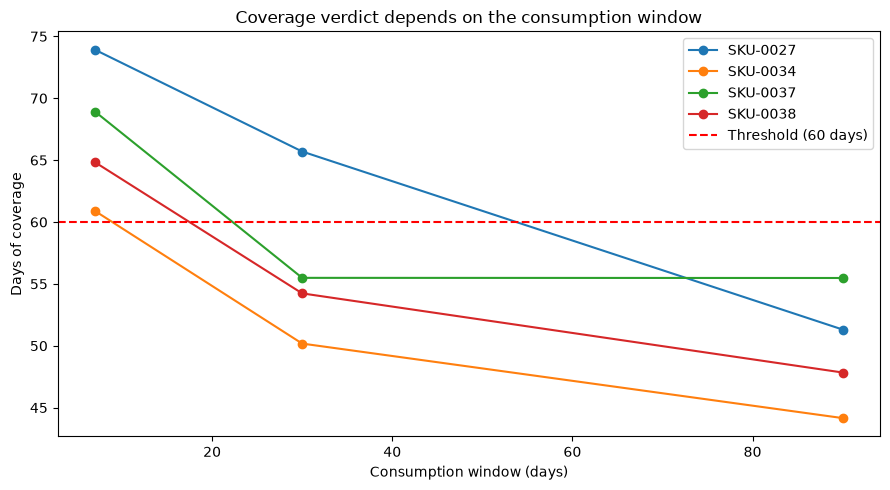

In [61]:
import matplotlib.pyplot as plt

flips = comparison[comparison["at_risk_7d"] != comparison["at_risk_90d"]]

fig, ax = plt.subplots(figsize=(9, 5))

windows = [7, 30, 90]
for _, row in flips.iterrows():
    coverages = [row["coverage_7d"], row["coverage_30d"], row["coverage_90d"]]
    ax.plot(windows, coverages, marker="o", label=row["sku_id"])

ax.axhline(60, color="red", linestyle="--", label="Threshold (60 days)")
ax.set_xlabel("Consumption window (days)")
ax.set_ylabel("Days of coverage")
ax.set_title("Coverage verdict depends on the consumption window")
ax.legend()
plt.tight_layout()
plt.show()

CONCLUSION

With a fixed threshold of 60 days, 4 out of 40 products (10%) changed their risk classification depending only on the consumption window chosen. The stock, the product, and the threshold were identical — only the methodological choice of window changed the verdict.

The takeaway is not "pick the right threshold". It is that the consumption window is the real decision, and it should be:

Chosen according to each product's demand pattern (fast-moving → shorter window; slow or irregular → longer window),
Documented explicitly, and
Reported together with its sensitivity, rather than hidden behind a single comfortable number.

Choosing an honest analysis over a convenient number is what separates a useful report from a cosmetic one.